# Image Model — Transfer Learning + Fine-Tuned EfficientNet

**Dataset:** CASIA 2.0 — preprocessed as `casia_train.npz`, `casia_val.npz`, `casia_test.npz`

**Task:** Binary classification — Authentic (0) vs Tampered (1)

**Two models in this notebook:**
1. **ResNet50 baseline** — frozen backbone, only final layer trained (fast, for preliminary results)
2. **Fine-tuned EfficientNetB0** — backbone partially unfrozen and trained on CASIA data (better performance)

Run Sections 1–6 for the baseline. Run Sections 7–10 for the fine-tuned model after.

In [1]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Use GPU if available, otherwise CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print('✓ Imports done')

/Users/zan_zxc/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Using device: cpu
✓ Imports done


## 2. Load Preprocessed Data

Loads the `.npz` files saved during preprocessing.
Images are already resized to 224x224 and normalised with ImageNet mean/std.

In [5]:
TRAIN_NPZ = 'preprocessed_casia/casia_train.npz'
VAL_NPZ   = 'preprocessed_casia/casia_val.npz'
TEST_NPZ  = 'preprocessed_casia/casia_test.npz'

train_data = np.load(TRAIN_NPZ)
val_data   = np.load(VAL_NPZ)
test_data  = np.load(TEST_NPZ)

X_train, y_train = train_data['images'], train_data['labels']
X_val,   y_val   = val_data['images'],   val_data['labels']
X_test,  y_test  = test_data['images'],  test_data['labels']

print(f'Train: {X_train.shape}  labels: {y_train.shape}')
print(f'Val:   {X_val.shape}  labels: {y_val.shape}')
print(f'Test:  {X_test.shape}  labels: {y_test.shape}')
print(f'\nLabel distribution (train):')
print(f'  Authentic (0): {(y_train==0).sum()}')
print(f'  Tampered  (1): {(y_train==1).sum()}')

Train: (10091, 224, 224, 3)  labels: (10091,)
Val:   (1261, 224, 224, 3)  labels: (1261,)
Test:  (1262, 224, 224, 3)  labels: (1262,)

Label distribution (train):
  Authentic (0): 5993
  Tampered  (1): 4098


## 3. PyTorch Dataset & DataLoaders

In [4]:
class CASIADataset(Dataset):
    """Wraps numpy arrays into a PyTorch Dataset."""
    def __init__(self, images, labels):
        # PyTorch expects (N, C, H, W) — numpy arrays are (N, H, W, C) so we transpose
        self.images = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


BATCH_SIZE = 32

train_dataset = CASIADataset(X_train, y_train)
val_dataset   = CASIADataset(X_val,   y_val)
test_dataset  = CASIADataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 316
Val batches:   40
Test batches:  40


## 4. Training & Evaluation Helpers

In [6]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Run one training epoch. Returns average loss and accuracy."""
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model. Returns loss, accuracy, predictions, and true labels."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device).unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += images.size(0)

            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


def print_metrics(y_true, y_pred, split_name):
    print(f'\n=== {split_name} ===')
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred, target_names=['Authentic', 'Tampered']))


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Authentic', 'Tampered'],
                yticklabels=['Authentic', 'Tampered'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_history(train_losses, val_losses, train_accs, val_accs, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13)
    axes[0].plot(train_losses, label='Train')
    axes[0].plot(val_losses,   label='Val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[1].plot(train_accs, label='Train')
    axes[1].plot(val_accs,   label='Val')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

print('✓ Helper functions defined')

✓ Helper functions defined


---
# PART A — ResNet50 Baseline (Transfer Learning)

The ResNet50 backbone is **fully frozen** — its weights don't change at all.
Only the final classification layer is trained from scratch.
Fast to train, gives a solid benchmark number to beat.

## 5. Build ResNet50 Baseline

In [8]:
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all backbone layers
for param in resnet.parameters():
    param.requires_grad = False

# Replace final FC layer — ResNet50 outputs 2048 features, we map to 1 (binary)
resnet.fc = nn.Linear(resnet.fc.in_features, 1)
resnet = resnet.to(DEVICE)

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet.parameters())
print(f'Trainable params: {trainable:,} / {total:,} ({trainable/total*100:.2f}%)')

Trainable params: 2,049 / 23,510,081 (0.01%)


## 6. Train & Evaluate ResNet50 Baseline

In [9]:
EPOCHS_BASELINE = 10
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(resnet.fc.parameters(), lr=1e-3)

rn_train_losses, rn_val_losses = [], []
rn_train_accs,   rn_val_accs   = [], []
best_val_acc = 0

print(f'Training ResNet50 baseline for {EPOCHS_BASELINE} epochs...\n')

for epoch in range(EPOCHS_BASELINE):
    train_loss, train_acc = train_epoch(resnet, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = evaluate(resnet, val_loader, criterion, DEVICE)

    rn_train_losses.append(train_loss)
    rn_val_losses.append(val_loss)
    rn_train_accs.append(train_acc)
    rn_val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(resnet.state_dict(), 'resnet50_baseline_best.pth')

    print(f'Epoch {epoch+1:02d}/{EPOCHS_BASELINE} | '
          f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}')

print(f'\n✓ Best val accuracy: {best_val_acc:.4f}')

Training ResNet50 baseline for 10 epochs...



KeyboardInterrupt: 

: 

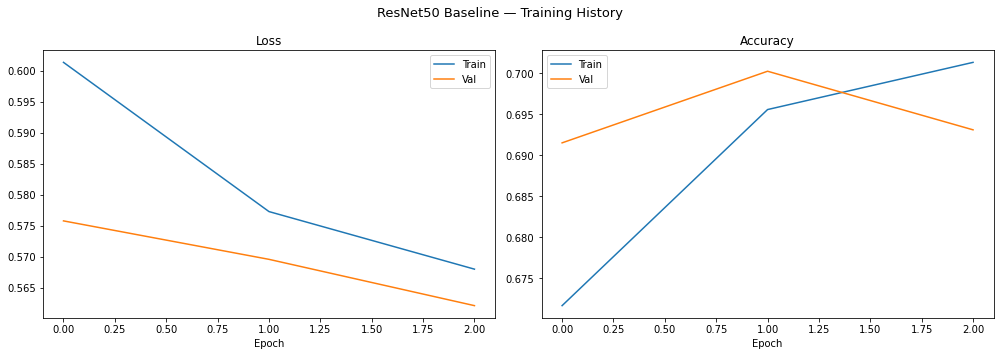

In [10]:
plot_history(rn_train_losses, rn_val_losses, rn_train_accs, rn_val_accs,
             'ResNet50 Baseline — Training History')


=== ResNet50 Baseline — Test Set (Preliminary Results) ===
Accuracy:  0.6957
Precision: 0.6314
Recall:    0.6043
F1 Score:  0.6175
              precision    recall  f1-score   support

   Authentic       0.74      0.76      0.75       749
    Tampered       0.63      0.60      0.62       513

    accuracy                           0.70      1262
   macro avg       0.68      0.68      0.68      1262
weighted avg       0.69      0.70      0.69      1262



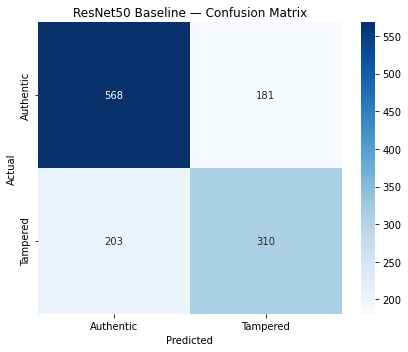

In [11]:
# Load best checkpoint and evaluate on test set — these are your preliminary results
resnet.load_state_dict(torch.load('resnet50_baseline_best.pth', map_location=DEVICE))
_, _, rn_test_pred, rn_test_true = evaluate(resnet, test_loader, criterion, DEVICE)

print_metrics(rn_test_true, rn_test_pred, 'ResNet50 Baseline — Test Set (Preliminary Results)')
plot_confusion_matrix(rn_test_true, rn_test_pred, 'ResNet50 Baseline — Confusion Matrix')

---
# PART B — Fine-Tuned EfficientNetB0

EfficientNet is a more modern and efficient architecture than ResNet.

**Two-phase training strategy:**
- **Phase 1:** Freeze backbone, train classifier head only (5 epochs) — warms up the new head
- **Phase 2:** Unfreeze last 3 backbone blocks, fine-tune everything at a lower learning rate (10 epochs)

The two-phase approach prevents the pretrained weights from being destroyed early in training.

## 7. Build EfficientNetB0

In [12]:
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze all layers to start
for param in efficientnet.parameters():
    param.requires_grad = False

# Replace classifier head — EfficientNetB0 outputs 1280 features
in_features = efficientnet.classifier[1].in_features
efficientnet.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 1)
)
efficientnet = efficientnet.to(DEVICE)

trainable = sum(p.numel() for p in efficientnet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in efficientnet.parameters())
print(f'Phase 1 — Trainable params: {trainable:,} / {total:,} ({trainable/total*100:.2f}%)')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/zan_zxc/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 36.3MB/s]


Phase 1 — Trainable params: 1,281 / 4,008,829 (0.03%)


## 8. Phase 1 — Train Classifier Head Only

In [13]:
EPOCHS_PHASE1 = 10
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(efficientnet.classifier.parameters(), lr=1e-3)

p1_train_losses, p1_val_losses = [], []
p1_train_accs,   p1_val_accs   = [], []

print(f'Phase 1 — Training classifier head for {EPOCHS_PHASE1} epochs...\n')

for epoch in range(EPOCHS_PHASE1):
    train_loss, train_acc = train_epoch(efficientnet, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = evaluate(efficientnet, val_loader, criterion, DEVICE)

    p1_train_losses.append(train_loss)
    p1_val_losses.append(val_loss)
    p1_train_accs.append(train_acc)
    p1_val_accs.append(val_acc)

    print(f'Epoch {epoch+1:02d}/{EPOCHS_PHASE1} | '
          f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}')

print('\n✓ Phase 1 complete')

Phase 1 — Training classifier head for 2 epochs...

Epoch 01/2 | Train Loss: 0.6398  Acc: 0.6301 | Val Loss: 0.6199  Acc: 0.6439
Epoch 02/2 | Train Loss: 0.6122  Acc: 0.6647 | Val Loss: 0.6078  Acc: 0.6519

✓ Phase 1 complete


## 9. Phase 2 — Unfreeze Backbone & Fine-Tune

In [15]:
# Unfreeze last 3 blocks of EfficientNetB0 backbone (features[6], [7], [8])
for block in [efficientnet.features[6], efficientnet.features[7], efficientnet.features[8]]:
    for param in block.parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in efficientnet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in efficientnet.parameters())
print(f'Phase 2 — Trainable params: {trainable:,} / {total:,} ({trainable/total*100:.2f}%)')

EPOCHS_PHASE2 = 10
# Lower LR — important to not destroy pretrained weights
optimizer = optim.Adam(filter(lambda p: p.requires_grad, efficientnet.parameters()), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)  # halve LR every 3 epochs

p2_train_losses, p2_val_losses = [], []
p2_train_accs,   p2_val_accs   = [], []
best_val_acc = 0

print(f'\nPhase 2 — Fine-tuning for {EPOCHS_PHASE2} epochs...\n')

for epoch in range(EPOCHS_PHASE2):
    train_loss, train_acc = train_epoch(efficientnet, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = evaluate(efficientnet, val_loader, criterion, DEVICE)
    scheduler.step()

    p2_train_losses.append(train_loss)
    p2_val_losses.append(val_loss)
    p2_train_accs.append(train_acc)
    p2_val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(efficientnet.state_dict(), 'efficientnet_finetuned_best.pth')

    print(f'Epoch {epoch+1:02d}/{EPOCHS_PHASE2} | '
          f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | '
          f'LR: {scheduler.get_last_lr()[0]:.2e}')

print(f'\n✓ Best val accuracy: {best_val_acc:.4f}')

Phase 2 — Trainable params: 3,157,021 / 4,008,829 (78.75%)

Phase 2 — Fine-tuning for 3 epochs...

Epoch 01/3 | Train Loss: 0.5491  Acc: 0.7111 | Val Loss: 0.5415  Acc: 0.7185 | LR: 1.00e-04
Epoch 02/3 | Train Loss: 0.4673  Acc: 0.7683 | Val Loss: 0.5354  Acc: 0.7193 | LR: 1.00e-04
Epoch 03/3 | Train Loss: 0.4090  Acc: 0.8029 | Val Loss: 0.5374  Acc: 0.7415 | LR: 5.00e-05

✓ Best val accuracy: 0.7415


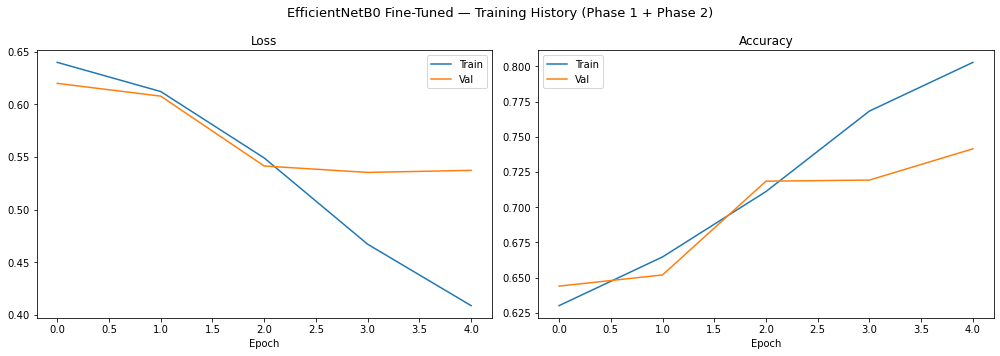

In [16]:
# Combined training history (Phase 1 + Phase 2)
plot_history(
    p1_train_losses + p2_train_losses,
    p1_val_losses   + p2_val_losses,
    p1_train_accs   + p2_train_accs,
    p1_val_accs     + p2_val_accs,
    'EfficientNetB0 Fine-Tuned — Training History (Phase 1 + Phase 2)'
)

## 10. Final Test Set Evaluation — EfficientNetB0


=== EfficientNetB0 Fine-Tuned — Test Set ===
Accuracy:  0.7266
Precision: 0.6438
Recall:    0.7329
F1 Score:  0.6855
              precision    recall  f1-score   support

   Authentic       0.80      0.72      0.76       749
    Tampered       0.64      0.73      0.69       513

    accuracy                           0.73      1262
   macro avg       0.72      0.73      0.72      1262
weighted avg       0.74      0.73      0.73      1262



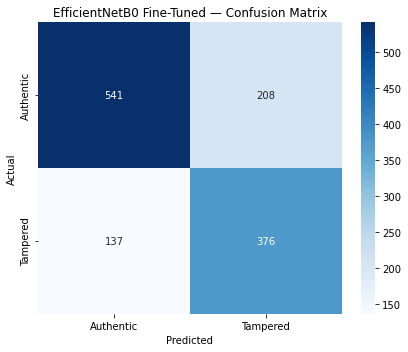

In [17]:
efficientnet.load_state_dict(torch.load('efficientnet_finetuned_best.pth', map_location=DEVICE))
_, _, en_test_pred, en_test_true = evaluate(efficientnet, test_loader, criterion, DEVICE)

print_metrics(en_test_true, en_test_pred, 'EfficientNetB0 Fine-Tuned — Test Set')
plot_confusion_matrix(en_test_true, en_test_pred, 'EfficientNetB0 Fine-Tuned — Confusion Matrix')

## 11. Model Comparison Summary

                           Accuracy  Precision  Recall  F1 Score
Model                                                           
ResNet50 Baseline            0.6957     0.6314  0.6043    0.6175
EfficientNetB0 Fine-Tuned    0.7266     0.6438  0.7329    0.6855


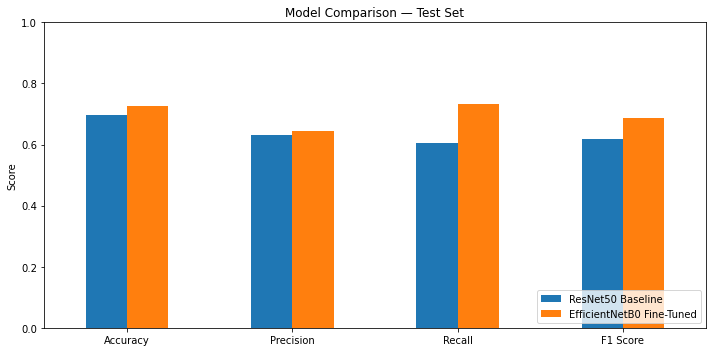

: 

In [18]:
summary = {
    'Model':     ['ResNet50 Baseline', 'EfficientNetB0 Fine-Tuned'],
    'Accuracy':  [accuracy_score(rn_test_true, rn_test_pred),  accuracy_score(en_test_true, en_test_pred)],
    'Precision': [precision_score(rn_test_true, rn_test_pred), precision_score(en_test_true, en_test_pred)],
    'Recall':    [recall_score(rn_test_true, rn_test_pred),    recall_score(en_test_true, en_test_pred)],
    'F1 Score':  [f1_score(rn_test_true, rn_test_pred),        f1_score(en_test_true, en_test_pred)],
}

summary_df = pd.DataFrame(summary).set_index('Model')
print(summary_df.round(4).to_string())

summary_df.T.plot(kind='bar', figsize=(10, 5), rot=0)
plt.title('Model Comparison — Test Set')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()